In [58]:
import random
import numpy as np


# ============================================================
# Edge occurrences in the embedding
# ============================================================

def edge_occurrences(G):
    """
    Create the list of edge occurrences.

    E[0] = None because Sage permutations are 1-indexed.

    Each edge occurrence has form:

        (v, w, s)

    where:
        v -> w is an oriented copy of an edge,
        s is 0 or 1.
    """
    E = [None]

    for v in G.vertices():
        for w in G.neighbors(v):
            for s in [0, 1]:
                E.append((v, w, s))

    return E


def edge_occurrence_index(E):
    """
    Fast lookup dictionary:

        (v, w, s) -> index in E
    """
    return {E[i]: i for i in range(1, len(E))}


def underlying_edge(e):
    """
    Convert an oriented edge (u,v) to an unoriented edge.
    """
    u, v = e
    return tuple(sorted((u, v)))


def reverse_edge(e):
    """
    Reverse an oriented edge.
    """
    u, v = e
    return (v, u)


def average(values):
    """
    Average using NumPy.
    """
    return np.mean(values)


# ============================================================
# Random embedding: (pi, lambda)
# ============================================================

def random_pi(G, I):
    """
    Construct the vertex rotation permutation pi.

    Around each vertex, choose a random cyclic order of neighbors.
    """
    pi_cycles = []

    for v in G.vertices():
        N = list(G.neighbors(v))
        random.shuffle(N)

        for x, y in zip(N, N[1:] + [N[0]]):
            pi_cycles.append((
                I[(v, x, 1)],
                I[(v, y, 0)]
            ))

    return Permutation(pi_cycles)


def random_lambda(G, I, do_twist=True):
    """
    Construct the edge-sign permutation lambda.

    If do_twist=True, each edge receives a random twist.
    If do_twist=False, all edges use the same untwisted choice.
    """
    lambda_cycles = []

    for u, v in G.edges(labels=False):
        t = random.randint(0, 1) if do_twist else 1

        lambda_cycles.append((
            I[(u, v, 0)],
            I[(v, u, t)]
        ))

        lambda_cycles.append((
            I[(u, v, 1)],
            I[(v, u, (t + 1) % 2)]
        ))

    return Permutation(lambda_cycles)


def random_embedding(G, do_twist=True, return_data=False):
    """
    Construct a random embedding (pi, lambda).

    The facial permutation is:

        phi = pi * lambda

    The cycles of phi are the facial walks.
    """
    E = edge_occurrences(G)
    I = edge_occurrence_index(E)

    pi = random_pi(G, I)
    lam = random_lambda(G, I, do_twist=do_twist)

    phi = pi * lam

    if return_data:
        return phi, pi, lam, E

    return phi


# ============================================================
# Facial walks
# ============================================================

def facial_walks_as_edge_occurrences(G, do_twist=True):
    """
    Return facial walks as cycles of edge-occurrence indices.
    """
    phi = random_embedding(G, do_twist=do_twist)
    return phi.cycle_tuples()


def facial_walks_as_edges(G, do_twist=True):
    """
    Return facial walks as unoriented graph edges.
    """
    phi, pi, lam, E = random_embedding(
        G,
        do_twist=do_twist,
        return_data=True
    )

    walks = []

    for face in phi.cycle_tuples():
        F = []

        for i in face:
            v, w, s = E[i]
            F.append(underlying_edge((v, w)))

        walks.append(F)

    return walks


def facial_walks_as_oriented_edges(G, do_twist=True):
    """
    Return facial walks as oriented edge occurrences.

    Each occurrence is:

        (u, v)

    meaning the edge is traversed from u to v.
    """
    phi, pi, lam, E = random_embedding(
        G,
        do_twist=do_twist,
        return_data=True
    )

    walks = []

    for face in phi.cycle_tuples():
        F = []

        for i in face:
            v, w, s = E[i]
            F.append((v, w))

        walks.append(F)

    return walks


def number_of_faces(G, do_twist=True):
    """
    Return the number of facial walks.

    Because this model has two parallel copies of each facial walk,
    we divide by 2.
    """
    phi = random_embedding(G, do_twist=do_twist)
    return len(phi.cycle_tuples()) / 2


def sample_number_of_faces(G, samples=10, do_twist=True):
    """
    Sample the number of facial walks.
    """
    return [
        number_of_faces(G, do_twist=do_twist)
        for _ in range(samples)
    ]


# ============================================================
# Singular and regular links in facial-diagram notation
# ============================================================

def count_good_bad_regular(G, do_twist=True):
    """
    Return:

        [good_singular, bad_singular, regular]

    In the facial-diagram notation:

        sign '-' = good singular link
                 = same oriented edge appears twice in one face

        sign '+' = bad singular link
                 = opposite orientations appear in one face

        regular  = edge appears in two different faces

    The edge-occurrence model counts singular links twice,
    so singular counts are divided by 2.
    """
    faces = facial_walks_as_oriented_edges(G, do_twist=do_twist)

    good_singular = 0
    bad_singular = 0

    for F in faces:
        for i in range(len(F)):
            for j in range(i + 1, len(F)):
                e = F[i]
                f = F[j]

                if e == f:
                    good_singular += 1

                elif e == reverse_edge(f):
                    bad_singular += 1

    good_singular = good_singular / 2
    bad_singular = bad_singular / 2

    regular = G.num_edges() - good_singular - bad_singular

    return [good_singular, bad_singular, regular]


def count_singular(G, do_twist=True):
    """
    Return the total number of singular links.
    """
    good, bad, regular = count_good_bad_regular(
        G,
        do_twist=do_twist
    )

    return good + bad


def sample_good_bad_regular(G, samples=10, do_twist=True):
    """
    Sample:

        [good singular, bad singular, regular]
    """
    return [
        count_good_bad_regular(G, do_twist=do_twist)
        for _ in range(samples)
    ]


def expected_good_bad_regular(G, samples=100, do_twist=True):
    """
    Estimate expected values of:

        good singular links,
        bad singular links,
        regular links.
    """
    values = sample_good_bad_regular(
        G,
        samples=samples,
        do_twist=do_twist
    )

    good_values = [x[0] for x in values]
    bad_values = [x[1] for x in values]
    regular_values = [x[2] for x in values]

    return [
        average(good_values),
        average(bad_values),
        average(regular_values)
    ]


# ============================================================
# Facial diagram data
# ============================================================

def facial_diagram_data(G, do_twist=True):
    """
    Return a dictionary describing the facial diagram H.

    Output keys:

        "faces":
            facial walks as oriented edges

        "good_singular_links":
            singular links with sign '-'

        "bad_singular_links":
            singular links with sign '+'

        "regular_count":
            number of regular links
    """
    faces = facial_walks_as_oriented_edges(G, do_twist=do_twist)

    good_links = []
    bad_links = []

    for face_id, F in enumerate(faces):
        for i in range(len(F)):
            for j in range(i + 1, len(F)):
                e = F[i]
                f = F[j]

                if e == f:
                    good_links.append({
                        "edge": underlying_edge(e),
                        "face": face_id,
                        "positions": (i, j),
                        "sign": "-"
                    })

                elif e == reverse_edge(f):
                    bad_links.append({
                        "edge": underlying_edge(e),
                        "face": face_id,
                        "positions": (i, j),
                        "sign": "+"
                    })

    good_count = len(good_links) / 2
    bad_count = len(bad_links) / 2
    regular_count = G.num_edges() - good_count - bad_count

    return {
        "faces": faces,
        "good_singular_links": good_links,
        "bad_singular_links": bad_links,
        "good_count": good_count,
        "bad_count": bad_count,
        "regular_count": regular_count
    }


# ============================================================
# Crossing singular links
# ============================================================

def are_crossing(pos1, pos2):
    """
    Two singular links cross if their endpoints alternate:

        e1, e2, e1, e2
    """
    a, b = sorted(pos1)
    c, d = sorted(pos2)

    return (a < c < b < d) or (c < a < d < b)


def crossing_singular_links(G, do_twist=True):
    """
    Return crossing pairs of singular links.
    """
    H = facial_diagram_data(G, do_twist=do_twist)

    singular_links = (
        H["good_singular_links"] +
        H["bad_singular_links"]
    )

    crossings = []

    for i in range(len(singular_links)):
        for j in range(i + 1, len(singular_links)):
            L1 = singular_links[i]
            L2 = singular_links[j]

            if L1["face"] == L2["face"]:
                if are_crossing(L1["positions"], L2["positions"]):
                    crossings.append((L1, L2))

    return crossings


# ============================================================
# CDC-related sampling
# ============================================================

def has_no_singular_links(G, do_twist=True):
    """
    Return True if this sampled embedding has no singular links.
    """
    return count_singular(G, do_twist=do_twist) == 0


def number_of_CDC_samples(G, samples=100, do_twist=True):
    """
    Count how many sampled embeddings have no singular links.
    """
    count = 0

    for _ in range(samples):
        if has_no_singular_links(G, do_twist=do_twist):
            count += 1

    return count


def sample_singular_counts(G, samples=100, do_twist=True):
    """
    Sample total number of singular links.
    """
    return [
        count_singular(G, do_twist=do_twist)
        for _ in range(samples)
    ]


# ============================================================
# Plot
# ============================================================

def diagram_good_bad_regular(G, samples=100, do_twist=True):
    """
    Plot sampled points:

        x-axis = good singular links, sign '-'
        y-axis = bad singular links, sign '+'
    """
    m = G.num_edges()

    values = sample_good_bad_regular(
        G,
        samples=samples,
        do_twist=do_twist
    )

    red_points = [(x[0], x[1]) for x in values if x[1] != 0]
    black_points = [(x[0], x[1]) for x in values if x[1] == 0]

    P = line([(m, 0), (0, m), (0, 0), (m, 0)])
    P += points(red_points, color="red", size=40)
    P += points(black_points, color="black", size=50)

    return P

In [59]:
G = graphs.PetersenGraph()

sample_good_bad_regular(G, samples=10, do_twist=True)

[[5, 10, 0],
 [10, 5, 0],
 [5, 5, 5],
 [8, 7, 0],
 [9, 6, 0],
 [2, 3, 10],
 [7, 3, 5],
 [4, 5, 6],
 [7, 3, 5],
 [7, 3, 5]]

In [60]:
sample_good_bad_regular(G, samples=7, do_twist=True)

[[9, 6, 0], [9, 6, 0], [4, 5, 6], [6, 4, 5], [3, 3, 9], [9, 6, 0], [4, 6, 5]]

In [61]:
count_good_bad_regular(G, do_twist=True)[:2]

[6, 4]

In [62]:
expected_good_bad_regular(G, samples=5, do_twist=True)

[5.6, 3.0, 6.4]

In [63]:
# ------------------------------------------------------------
# Petersen graph
# ------------------------------------------------------------

print("----- Petersen Graph -----")

G = graphs.PetersenGraph()

print("Sample [good singular, bad singular, regular]:")
print(sample_good_bad_regular(G, samples=7, do_twist=True))

----- Petersen Graph -----
Sample [good singular, bad singular, regular]:
[[3, 0, 12], [2, 3, 10], [3, 7, 5], [8, 7, 0], [7, 3, 5], [2, 1, 12], [9, 6, 0]]


In [64]:
print("Single sample (only singular counts):")
print(count_good_bad_regular(G, do_twist=True)[:2])



Single sample (only singular counts):
[4, 2]


In [65]:
print("Expected values:")
print(expected_good_bad_regular(G, samples=100, do_twist=True))

Expected values:
[5.15, 4.49, 5.36]


In [66]:
print("Number of faces:")
print(number_of_faces(G))

Number of faces:
1


In [67]:
print("Sample number of faces:")
print(sample_number_of_faces(G, samples=20))

Sample number of faces:
[1, 2, 1, 3, 1, 1, 1, 2, 2, 3, 1, 2, 1, 2, 3, 3, 2, 3, 1, 3]


In [68]:
print("Total singular links:")
print(count_singular(G))

Total singular links:
15


In [69]:
print("Sample total singular links:")
print(sample_singular_counts(G, samples=20))

Sample total singular links:
[15, 15, 10, 15, 15, 10, 15, 4, 15, 10, 15, 7, 5, 5, 15, 15, 15, 6, 15, 10]


In [70]:
print("Number of CDC samples:")
print(number_of_CDC_samples(G, samples=100))

Number of CDC samples:
1


In [71]:
print("Crossing singular links:")
print(crossing_singular_links(G))

Crossing singular links:
[({'edge': (6, 8), 'face': 0, 'positions': (3, 16), 'sign': '-'}, {'edge': (1, 6), 'face': 0, 'positions': (12, 17), 'sign': '-'}), ({'edge': (6, 8), 'face': 0, 'positions': (3, 16), 'sign': '-'}, {'edge': (5, 8), 'face': 0, 'positions': (2, 8), 'sign': '+'}), ({'edge': (3, 8), 'face': 0, 'positions': (7, 15), 'sign': '-'}, {'edge': (1, 6), 'face': 0, 'positions': (12, 17), 'sign': '-'}), ({'edge': (3, 8), 'face': 0, 'positions': (7, 15), 'sign': '-'}, {'edge': (5, 8), 'face': 0, 'positions': (2, 8), 'sign': '+'}), ({'edge': (3, 8), 'face': 0, 'positions': (7, 15), 'sign': '-'}, {'edge': (6, 9), 'face': 0, 'positions': (4, 11), 'sign': '+'}), ({'edge': (1, 6), 'face': 5, 'positions': (2, 7), 'sign': '-'}, {'edge': (6, 8), 'face': 5, 'positions': (3, 16), 'sign': '-'}), ({'edge': (1, 6), 'face': 5, 'positions': (2, 7), 'sign': '-'}, {'edge': (3, 8), 'face': 5, 'positions': (4, 12), 'sign': '-'}), ({'edge': (6, 8), 'face': 5, 'positions': (3, 16), 'sign': '-'}, {

Facial diagram plot:


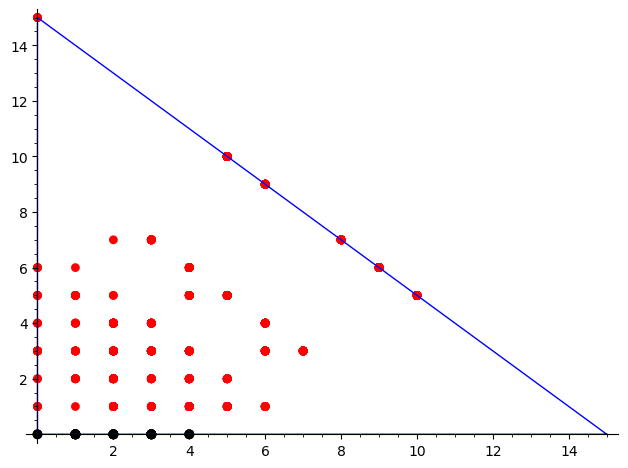

In [72]:
print("Facial diagram plot:")
show(diagram_good_bad_regular(G, samples=1000))

In [73]:
# ------------------------------------------------------------
# Complete graph K4
# ------------------------------------------------------------

print("\n\n----- Complete Graph K4 -----")

K4 = graphs.CompleteGraph(4)

print(sample_good_bad_regular(K4, samples=100))



----- Complete Graph K4 -----
[[2, 1, 3], [3, 3, 0], [3, 3, 0], [1, 0, 5], [2, 1, 3], [4, 2, 0], [4, 2, 0], [2, 0, 4], [3, 3, 0], [4, 2, 0], [2, 1, 3], [3, 3, 0], [0, 3, 3], [3, 3, 0], [3, 3, 0], [2, 1, 3], [3, 3, 0], [4, 2, 0], [2, 1, 3], [2, 1, 3], [3, 3, 0], [4, 2, 0], [2, 1, 3], [1, 0, 5], [2, 1, 3], [1, 1, 4], [1, 1, 4], [0, 3, 3], [3, 3, 0], [0, 3, 3], [4, 2, 0], [3, 3, 0], [3, 3, 0], [3, 3, 0], [1, 1, 4], [1, 0, 5], [0, 2, 4], [4, 2, 0], [4, 2, 0], [1, 0, 5], [3, 3, 0], [2, 1, 3], [3, 3, 0], [4, 2, 0], [2, 1, 3], [1, 1, 4], [1, 0, 5], [1, 0, 5], [1, 0, 5], [2, 1, 3], [1, 0, 5], [3, 3, 0], [2, 1, 3], [1, 0, 5], [0, 3, 3], [0, 2, 4], [1, 1, 4], [3, 3, 0], [1, 1, 4], [3, 3, 0], [4, 2, 0], [0, 3, 3], [2, 1, 3], [2, 1, 3], [2, 1, 3], [4, 2, 0], [0, 3, 3], [2, 1, 3], [3, 3, 0], [1, 0, 5], [3, 3, 0], [3, 3, 0], [3, 3, 0], [0, 2, 4], [3, 3, 0], [0, 3, 3], [3, 3, 0], [3, 3, 0], [1, 0, 5], [4, 2, 0], [1, 0, 5], [1, 1, 4], [3, 3, 0], [0, 3, 3], [4, 2, 0], [1, 1, 4], [4, 2, 0], [3, 3, 0],

In [74]:
print(expected_good_bad_regular(K4, samples=100))

[2.15, 1.63, 2.22]


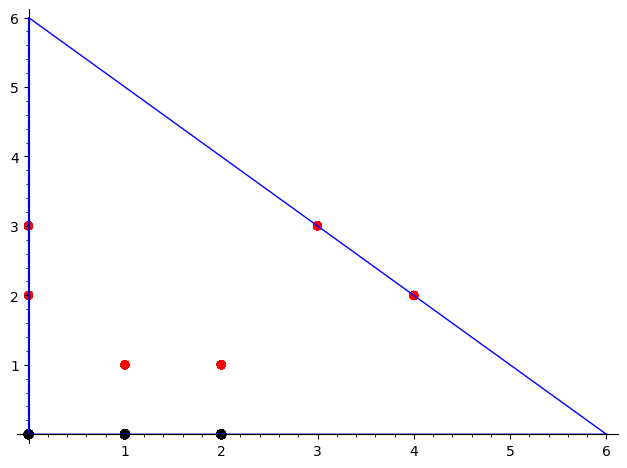

In [75]:
show(diagram_good_bad_regular(K4, samples=1000))

In [76]:
# ------------------------------------------------------------
# Flower snark
# ------------------------------------------------------------

print("\n\n----- Flower Snark -----")

FL = graphs.FlowerSnark()

print(expected_good_bad_regular(FL, samples=100))



----- Flower Snark -----
[10.61, 10.23, 9.16]


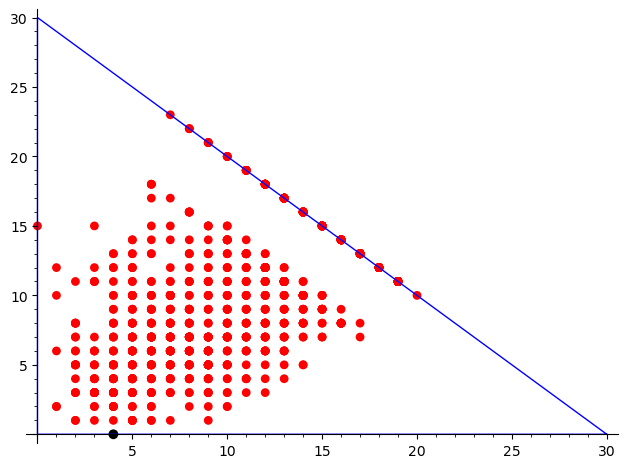

In [77]:
show(diagram_good_bad_regular(FL, samples=1000))

In [78]:
# ------------------------------------------------------------
# Blanuša snarks
# ------------------------------------------------------------

print("\n\n----- Blanusa Snarks -----")

B1 = graphs.BlanusaFirstSnarkGraph()
B2 = graphs.BlanusaSecondSnarkGraph()

print("Blanusa 1 expectation:")
print(expected_good_bad_regular(B1, samples=100))



----- Blanusa Snarks -----
Blanusa 1 expectation:
[9.4, 8.8, 8.8]


In [79]:
print("Blanusa 2 expectation:")
print(expected_good_bad_regular(B2, samples=100))

Blanusa 2 expectation:
[9.73, 8.87, 8.4]


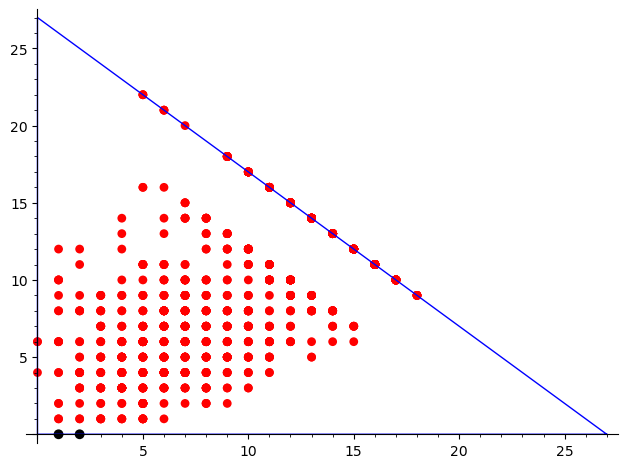

In [80]:
show(diagram_good_bad_regular(B1, samples=1000))

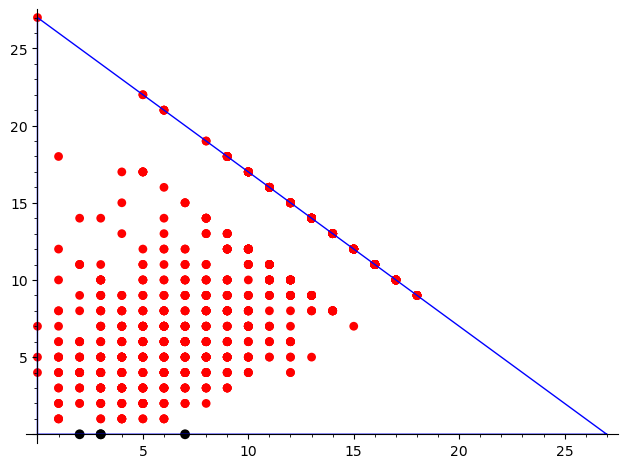

In [81]:
show(diagram_good_bad_regular(B2, samples=1000))

In [82]:
L = sample_good_bad_regular(B2, samples=1000)

print("\nSamples with no bad singular links (+):")
print(len([x for x in L if x[1] == 0]))


Samples with no bad singular links (+):
5


In [83]:
print("Samples with no good singular links (-):")
print(len([x for x in L if x[0] == 0]))

Samples with no good singular links (-):
0




----- Random Cubic Graphs (small sizes) -----

Random cubic graph on 10 vertices
Expected values:
[5.46, 4.86, 4.68]


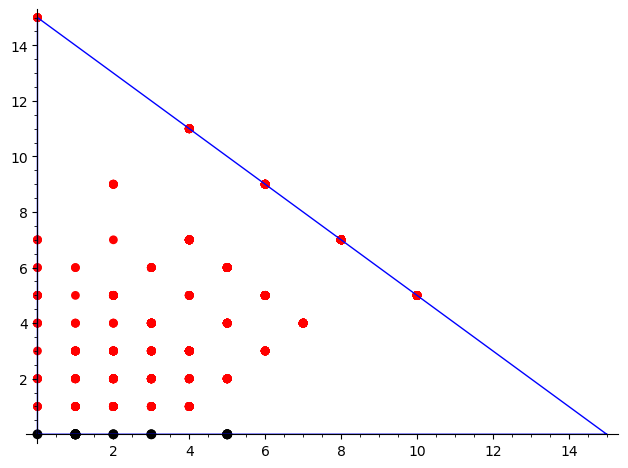


Random cubic graph on 20 vertices
Expected values:
[10.25, 10.01, 9.74]


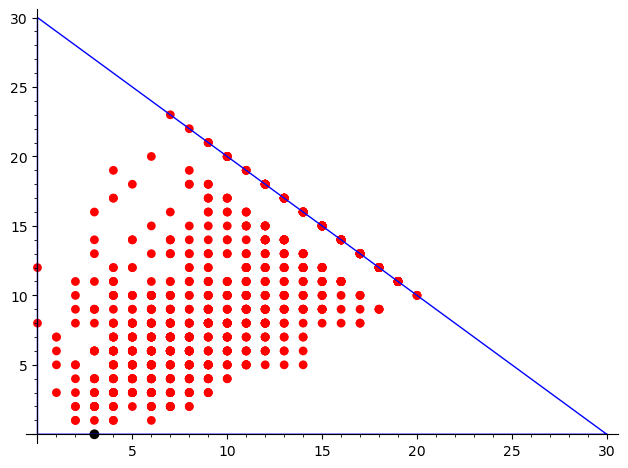


Random cubic graph on 26 vertices
Expected values:
[13.89, 13.53, 11.58]


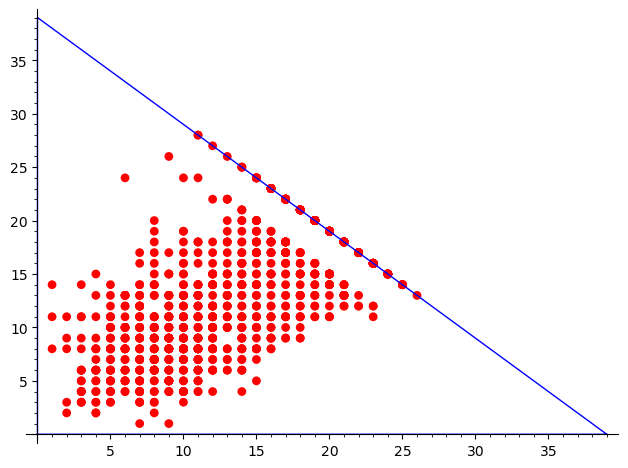


Random cubic graph on 30 vertices
Expected values:
[15.29, 13.99, 15.72]


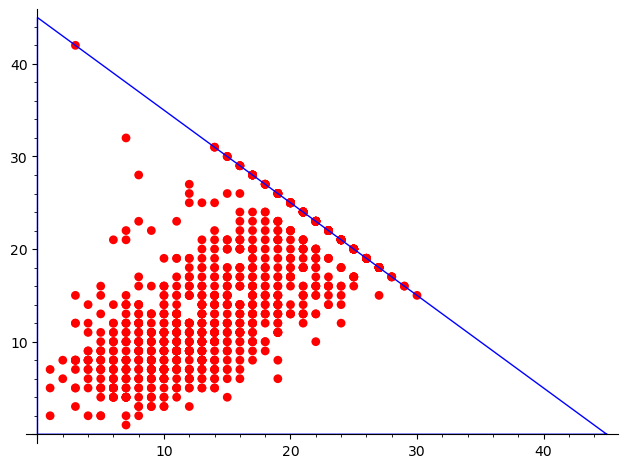


Random cubic graph on 40 vertices
Expected values:
[20.08, 19.0, 20.92]


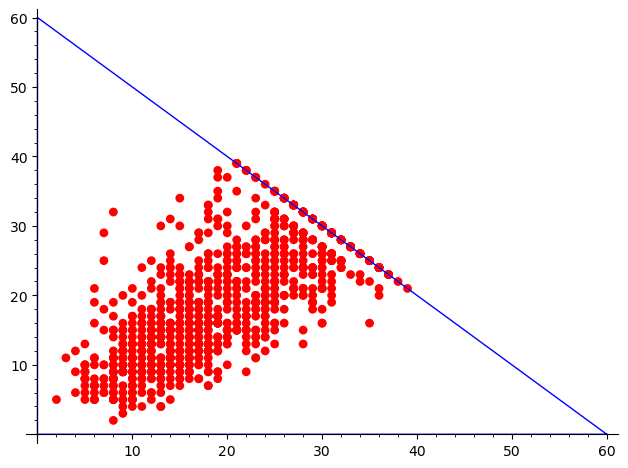

In [84]:
# ------------------------------------------------------------
# Random cubic graphs (small sizes)
# ------------------------------------------------------------

print("\n\n----- Random Cubic Graphs (small sizes) -----")

sizes = [10, 20, 26, 30, 40]

for n in sizes:
    print(f"\nRandom cubic graph on {n} vertices")

    R = graphs.RandomRegular(3, n)

    print("Expected values:")
    print(expected_good_bad_regular(R, samples=100))

    show(diagram_good_bad_regular(R, samples=1000))




----- Random Cubic Graph on 50 vertices -----
[23.4, 22.89, 28.71]


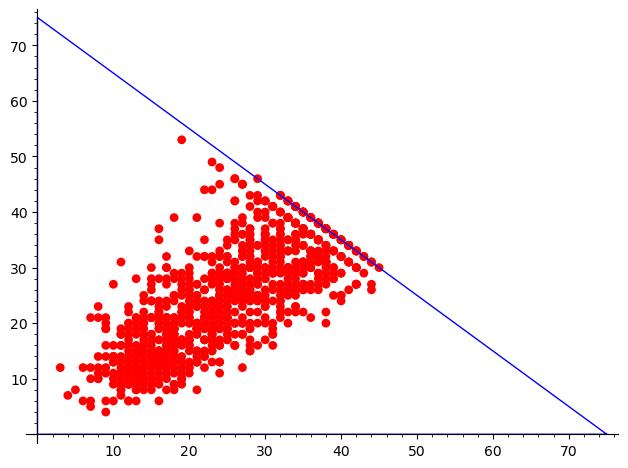

In [85]:
# ------------------------------------------------------------
# Random cubic graph on 50 vertices
# ------------------------------------------------------------

print("\n\n----- Random Cubic Graph on 50 vertices -----")

R50 = graphs.RandomRegular(3, 50)

print(expected_good_bad_regular(R50, samples=100))
show(diagram_good_bad_regular(R50, samples=1000))




----- Random Cubic Graph on 70 vertices -----
[35.94, 35.73, 33.33]


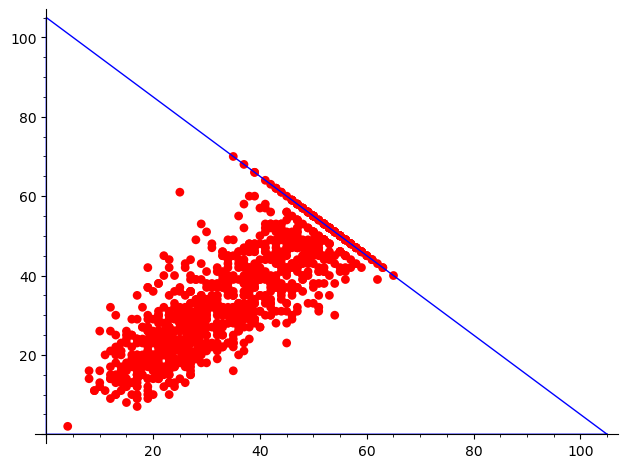

In [86]:
# ------------------------------------------------------------
# Random cubic graph on 70 vertices
# ------------------------------------------------------------

print("\n\n----- Random Cubic Graph on 70 vertices -----")

R70 = graphs.RandomRegular(3, 70)

print(expected_good_bad_regular(R70, samples=100))
show(diagram_good_bad_regular(R70, samples=1000))



----- Random Cubic Graph on 100 vertices -----
[50.39, 50.36, 49.25]

Samples with no bad singular links (+):
0


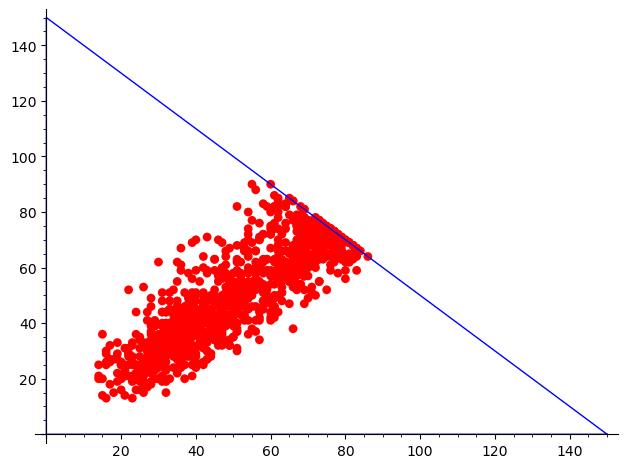

In [87]:
# ------------------------------------------------------------
# Random cubic graph on 100 vertices
# ------------------------------------------------------------

print("\n\n----- Random Cubic Graph on 100 vertices -----")

R100 = graphs.RandomRegular(3, 100)

print(expected_good_bad_regular(R100, samples=100))

L = sample_good_bad_regular(R100, samples=1000)

print("\nSamples with no bad singular links (+):")
print(len([x for x in L if x[1] == 0]))

show(diagram_good_bad_regular(R100, samples=1000))




----- Random Cubic Graph on 110 vertices -----
[58.33, 57.17, 49.5]


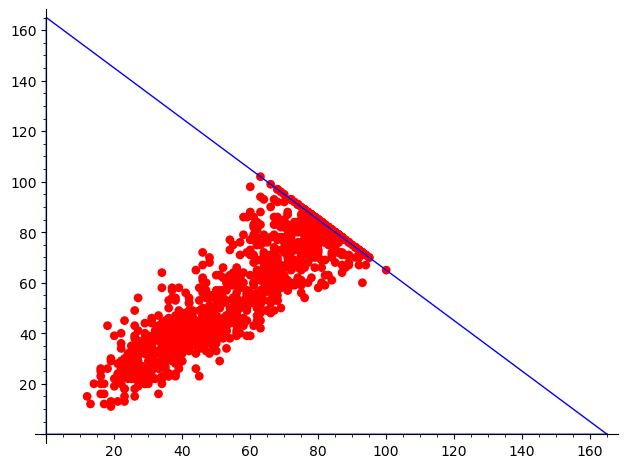

In [88]:
# ------------------------------------------------------------
# Random cubic graph on 110 vertices
# ------------------------------------------------------------

print("\n\n----- Random Cubic Graph on 110 vertices -----")

R110 = graphs.RandomRegular(3, 110)

print(expected_good_bad_regular(R110, samples=100))
show(diagram_good_bad_regular(R110, samples=1000))

In [89]:
# ------------------------------------------------------------
# Very large random cubic graph
# ------------------------------------------------------------

print("\n\n----- Random Cubic Graph on 10000 vertices -----")

R_big = graphs.RandomRegular(3, 10000)

print(expected_good_bad_regular(R_big, samples=1))



----- Random Cubic Graph on 10000 vertices -----
[4451.0, 4350.0, 6199.0]


In [ ]:
show(diagram_good_bad_regular(R_big, samples=10))